# Filter Atoms

Clean up extracted atoms from chesspublishing using a second LLM pass.

Actions (in priority order):
1. **Keep** — Concrete, verifiable positional facts about the move
2. **Contextualize** — Not self-contained; rewrite with missing context so it stands alone (keep as separate atom)
3. **Move to alternative** — About a different move, not the played one
4. **Remove** — Generic labels only (no positional content)

In [1]:
import json
import os
import random
import chess
import chess.svg
import openai
from IPython.display import display, SVG, Markdown, clear_output
from dotenv import load_dotenv

load_dotenv()

DIR = os.path.dirname(os.path.abspath('__file__'))
INPUT_PATH = os.path.join(DIR, 'data', 'extraction_included.jsonl')

with open(INPUT_PATH) as f:
    all_rows = [json.loads(line) for line in f]

print(f'Loaded {len(all_rows)} positions from {INPUT_PATH}')

total_atoms = sum(len(r['extracted'].get('reasoning', [])) for r in all_rows)
print(f'Total atoms: {total_atoms}')

client = openai.OpenAI()

Loaded 204 positions from /Users/ashwin/Documents/Princeton/chess/chess_annotation/evaluation/data/chesspublishing/data/extraction_included.jsonl
Total atoms: 343


In [2]:
def parse_json(text):
    """Parse JSON from LLM output, stripping markdown code fences if present."""
    text = text.strip()
    if text.startswith('```'):
        text = text.split('\n', 1)[1]
        if text.endswith('```'):
            text = text[:-3]
        text = text.strip()
    return json.loads(text)

---
# Part 1 — Filter pass

Classify each reasoning atom as keep / contextualize / move_to_alternative / remove.

Full position context (FEN, commentary, variation) is
sent to the LLM. Only reasoning atoms are classified.

In [3]:
FILTER_MODEL = 'gpt-5.4'

FILTER_PROMPT = """\
You are filtering extracted reasoning atoms from chess commentary.

You will receive the FULL extracted JSON for a position (FEN, move played,
original commentary, reasoning atoms, etc.)

Classify each REASONING atom as: keep / contextualize / move_to_alternative / remove.

KEEP an atom if it states a concrete, verifiable positional fact about what
the move does: attacks, defends, controls, pins, blocks, develops, opens/
closes lines, creates threats, prevents opponent plans, explains why a move
is bad, etc.

CONTEXTUALIZE an atom that has useful content but is not self-contained on
its own. An atom is not self-contained if it references a consequence,
position, or piece without enough context to verify it independently.

Each atom stays SEPARATE — do NOT combine multiple atoms into one. Instead,
add the missing context so each atom is independently verifiable.
  Original: "On e4 the knight controls d6 and f6"
  Contextualized: "After Nd2, the knight on e4 would control d6 and f6."
Output: {"action": "contextualize", "new_text": "After Nd2, ..."}

IMPORTANT: Only add REFERENTIAL context — which move, which piece, which
square, which position. Do NOT add new chess claims, analysis, or
consequences that were not in the original atom. The goal is to make the
existing claim self-contained, not to enrich it.

MOVE_TO_ALTERNATIVE if the atom describes an ALTERNATIVE move (a move NOT
played) and its consequences.
  Output: {"action": "move_to_alternative", "move": "Bf4", "text": "..."}
  You may paraphrase the text so it reads naturally.

Conclusion vs. detailed analysis of alternatives:
- A CONCLUSION that the played move avoids or is better than an alternative
  is KEEP: "Qh4 avoids the inferior Qg5" -> KEEP.
- A DETAILED ANALYSIS of what happens after the alternative move is
  MOVE_TO_ALTERNATIVE: "After 32.Qc1 Nxd4 33.Bxd4 Rxd4, Black threatens
  Rd3" -> MOVE_TO_ALTERNATIVE for Qc1.
- When an atom MIXES both (conclusion + detailed line), SPLIT it using
  kept_brief:
  {"action": "move_to_alternative", "move": "Qc1",
   "text": "After 32.Qc1 Nxd4 33.Bxd4 Rxd4, Black threatens Rd3.",
   "kept_brief": "Qb2 avoids Qc1, which leads to dangerous threats on the d-file."}
  kept_brief stays in reasoning, text goes to the alternative.

REMOVE an atom ONLY if it is a generic label with no concrete positional
content. "Nbd2 is a typical Colle Attack manoeuvre." — naming an opening or
saying "typical/standard" without any positional claim is not a useful atom.

─── OUTPUT FORMAT ───

Output ONLY valid JSON:
{"atoms": [
  {"index": 0, "text": "...", "action": "keep"},
  {"index": 1, "text": "...", "action": "contextualize", "new_text": "..."},
  {"index": 2, "text": "...", "action": "move_to_alternative", "move": "Qc1",
   "text": "detailed line...", "kept_brief": "brief conclusion..."},
  {"index": 3, "text": "...", "action": "remove", "reason": "generic label"}
 ]
}

Be conservative: when in doubt, KEEP. Prefer CONTEXTUALIZE over REMOVE when
an atom has useful content but just lacks context. Prefer MOVE_TO_ALTERNATIVE
over REMOVE when the atom is about a different move.
"""

print(f'Filter model: {FILTER_MODEL}')
print(f'Filter prompt: {len(FILTER_PROMPT)} chars')

Filter model: gpt-5.4
Filter prompt: 3113 chars


In [4]:
def filter_atoms(row, model=FILTER_MODEL):
    """Classify each reasoning atom as keep/remove/contextualize/move_to_alternative."""
    extracted = row['extracted']
    reasoning = extracted.get('reasoning', [])

    all_atoms = [{'index': i, 'text': a} for i, a in enumerate(reasoning)]

    if not all_atoms:
        return {'atoms': [], 'filtered_reasoning': [],
                'alternatives': []}

    # Full context for the LLM
    context = {
        'fen': row['fen'],
        'move_uci': row['move_uci'],
        'move_san': row.get('move_san', ''),
        'annotation': row['annotation'],
        'is_mainline': row.get('is_mainline', True),
        'parent_comment': row.get('parent_comment', ''),
        'reasoning': reasoning,
    }
    # Include variation if present
    if extracted.get('variation'):
        context['variation'] = extracted['variation']

    atoms_text = '\n'.join(f'{a["index"]}. \"{a["text"]}\"' for a in all_atoms)
    user_msg = (
        f'Position data:\n```json\n{json.dumps(context, indent=2)}\n```\n\n'
        f'Reasoning atoms to classify:\n{atoms_text}'
    )

    resp = client.chat.completions.create(
        model=model,
        messages=[
            {'role': 'system', 'content': FILTER_PROMPT},
            {'role': 'user', 'content': user_msg},
        ],
        temperature=0,
        max_completion_tokens=2048,
    )
    text = resp.choices[0].message.content.strip()

    try:
        result = parse_json(text)
    except json.JSONDecodeError:
        return {'atoms': [], 'error': 'JSON parse error', 'raw': text,
                'filtered_reasoning': reasoning, 'alternatives': []}

    if 'atoms' not in result:
        return {'atoms': [], 'error': 'no atoms key',
                'filtered_reasoning': reasoning, 'alternatives': []}

    # Parse reasoning atom actions
    atoms_by_idx = {a['index']: a for a in result['atoms']}
    alternatives = []

    # Build filtered reasoning
    filtered_reasoning = []
    for atom_info in all_atoms:
        idx = atom_info['index']
        a = atoms_by_idx.get(idx, {})
        action = a.get('action', 'keep')

        if action == 'remove':
            continue
        if action == 'move_to_alternative':
            alternatives.append({
                'move': a.get('move', '?'),
                'text': a.get('text', ''),
            })
            # If kept_brief provided, add that to reasoning instead
            if a.get('kept_brief'):
                filtered_reasoning.append(a['kept_brief'])
            continue
        if action == 'contextualize' and a.get('new_text'):
            filtered_reasoning.append(a['new_text'])
        else:
            filtered_reasoning.append(atom_info['text'])

    return {
        'atoms': result['atoms'],
        'filtered_reasoning': filtered_reasoning,
        'alternatives': alternatives,
    }


def run_filter(row, model=FILTER_MODEL):
    """Run filter and build the output row."""
    result = filter_atoms(row, model=model)

    out_row = dict(row)
    filtered_extracted = dict(row['extracted'])
    filtered_extracted['reasoning'] = result['filtered_reasoning']

    # Store alternatives if any were produced
    alts = result['alternatives']
    if alts:
        # Group by move
        alt_by_move = {}
        for a in alts:
            move = a['move']
            if move not in alt_by_move:
                alt_by_move[move] = {'move': move, 'reasoning': []}
            alt_by_move[move]['reasoning'].append(a['text'])
        alt_list = list(alt_by_move.values())
        filtered_extracted['alternative'] = alt_list[0] if len(alt_list) == 1 else alt_list

    out_row['extracted'] = filtered_extracted

    return result, out_row


print('filter_atoms, run_filter ready')

filter_atoms, run_filter ready


### Filter sample: 20 positions

In [5]:
SEED = 45
N_SAMPLE = 20

rng = random.Random(SEED)
review_order = list(range(len(all_rows)))
rng.shuffle(review_order)

sample_rows = [all_rows[i] for i in review_order[:N_SAMPLE]]

sample_results = []
for i, row in enumerate(sample_rows):
    board = chess.Board(row['fen'])
    san = board.san(chess.Move.from_uci(row['move_uci']))
    print(f'[{i+1}/{N_SAMPLE}] {row["game"]} \u2014 {san}')
    result, out_row = run_filter(row)
    sample_results.append((row, result, out_row))

print(f'\nDone. {N_SAMPLE} positions filtered.')

[1/20] Shmeliov, D. vs Akopian, Vladimir Eduardovic — Rc5
[2/20] Tishin, Dmitry vs Kononenko, Dmitry — Ne4
[3/20] Rogozenco, Dorian vs Meier, Georg — g5
[4/20] Aronian, Levon vs Karjakin, Sergey — Bxf6
[5/20] Caruana, Fabiano vs Dominguez Perez, Leinier — O-O
[6/20] Vaganian, Rafael A vs Moreno Carnero, Javier — Qxe8
[7/20] Svidler, Peter vs Vachier Lagrave, Maxime — Rh3
[8/20] Kokarev, Dmitry vs Dvoirys, Semen I — Ne2
[9/20] Durarbayli, Vasif vs Yu, Yangyi — Nh4
[10/20] Anton Guijarro, David vs Adams, Michael — Bc6
[11/20] Nyman, Sture vs Bern, Ivar — Bg7
[12/20] Damljanovic, Branko vs Kindermann, Stefan — h6
[13/20] Dubov, Daniil vs Anton Guijarro, David — b4
[14/20] Kramnik, Vladimir vs Svidler, Peter — Nd4
[15/20] Gustafsson, Jan vs Kasparov, Sergey — Qg4
[16/20] Paravyan, David vs Carlsen, Magnus — h4
[17/20] Gonda, Laszlo vs Perunovic, Milos — e6
[18/20] Caruana, Fabiano vs Ding, Liren — Kf2
[19/20] Baumegger, Siegfried vs Eisenbeiser, Amadeus — Bxg4
[20/20] Melkumyan, Hrant vs A

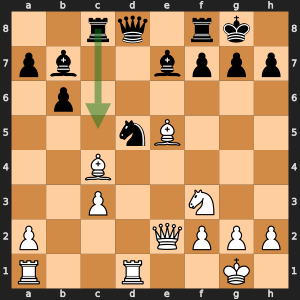

### [1/20] Shmeliov, D. vs Akopian, Vladimir Eduardovic — Black plays Rc5 (variation)

> 18...Rc5 defends the d5-knight solidly enough and gives Black's queen an escape route (from the awkward pin along the d-file) to a8.

*Context: is dangerous, the clever antidote*

#### Atom decisions
✅ Rc5 reinforces the knight on d5.

✅ Rc5 opens an escape route for the queen from the pin on the d-file to a8.

#### Resulting reasoning
1. Rc5 reinforces the knight on d5.
2. Rc5 opens an escape route for the queen from the pin on the d-file to a8.

**2 → 2 reasoning atoms**

---

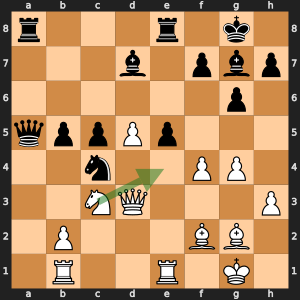

### [2/20] Tishin, Dmitry vs Kononenko, Dmitry — White plays Ne4 (variation)

> 23. Ne4 but then: 23... exf4 (wins a very useful pawn and after) 24. Nxc5 Nxb2 25. Qb3 Rxe1+ (the tactics favour Black, largely because of his more active dark-squared bishop:) 26. Bxe1 Qa7 ((a retreat which would certainly have been hard to spot some moves back)) 27. Bf2 Nc4 28. Nxd7 Qxd7 (leaves White struggling because) 29. Qxb5

*Context: was probably correct, although to have played this would have required strong nerves! Konenko probably disliked the look of*

#### Atom decisions
✅ After Ne4, Black can play exf4 and win a useful pawn.

🔄 In the line Nxc5 Nxb2 Qb3 Rxe1+ Bxe1, the tactics favor Black because Black's dark-squared bishop is more active.

  → **In the line after 23.Ne4 exf4 24.Nxc5 Nxb2 25.Qb3 Rxe1+ 26.Bxe1, the tactics favor Black because Black's dark-squared bishop is more active.**

🔄 After Bxe1, Black can retreat the queen to a7.

  → **In the line after 23.Ne4 exf4 24.Nxc5 Nxb2 25.Qb3 Rxe1+ 26.Bxe1, Black can retreat the queen to a7.**

🔄 After ...Nc4 and ...Qxd7, White is left struggling.

  → **In the line after 23.Ne4 exf4 24.Nxc5 Nxb2 25.Qb3 Rxe1+ 26.Bxe1 Qa7 27.Bf2 Nc4 28.Nxd7 Qxd7, White is left struggling.**

#### Resulting reasoning
1. After Ne4, Black can play exf4 and win a useful pawn.
2. In the line after 23.Ne4 exf4 24.Nxc5 Nxb2 25.Qb3 Rxe1+ 26.Bxe1, the tactics favor Black because Black's dark-squared bishop is more active.
3. In the line after 23.Ne4 exf4 24.Nxc5 Nxb2 25.Qb3 Rxe1+ 26.Bxe1, Black can retreat the queen to a7.
4. In the line after 23.Ne4 exf4 24.Nxc5 Nxb2 25.Qb3 Rxe1+ 26.Bxe1 Qa7 27.Bf2 Nc4 28.Nxd7 Qxd7, White is left struggling.

#### Variation
`23...exf4 24.Nxc5 Nxb2 25.Qb3 Rxe1+ 26.Bxe1 Qa7 27.Bf2 Nc4 28.Nxd7 Qxd7 29.Qxb5`

**4 → 4 reasoning atoms (3 contextualized)**

---

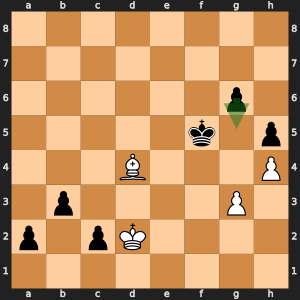

### [3/20] Rogozenco, Dorian vs Meier, Georg — Black plays g5 (mainline)

> This ultimately leads to the creation of a passed pawn on the kingside.

*Context: The queenside is blockaded for now, but what about the kingside?*

#### Atom decisions
✅ g5 starts Black's kingside pawn advance, which ultimately creates a passed pawn on the kingside.

#### Resulting reasoning
1. g5 starts Black's kingside pawn advance, which ultimately creates a passed pawn on the kingside.

**1 → 1 reasoning atoms**

---

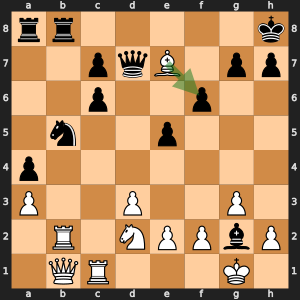

### [4/20] Aronian, Levon vs Karjakin, Sergey — White plays Bxf6 (variation)

> 25. Bxf6 and now: 25... gxf6 26. Kxg2 (and White is slightly better due to his superior structure); or 25... Bh3 26. Bxe5 Qd5 27. Nf3 Rf8 28. Rxb5 cxb5 29. Rxc7 Rxf3 30. Bxg7+ Kg8 31. exf3 (and White wins)

*Context: allows Aronian's great idea*

#### Atom decisions
✅ Bxf6 forces Black to choose between recapturing with gxf6 and accepting an inferior pawn structure, or playing Bh3 and allowing White to win by tactical means.

➡️ After gxf6, White can play Kxg2 and stand slightly better because of the superior pawn structure. → *alternative (gxf6)*

➡️ After Bh3, White has the tactical sequence Bxe5, Nf3, Rxb5, and Rxc7, after which White wins. → *alternative (Bh3)*

#### Resulting reasoning
1. Bxf6 forces Black to choose between recapturing with gxf6 and accepting an inferior pawn structure, or playing Bh3 and allowing White to win by tactical means.

#### Alternatives

**gxf6**:
  - After gxf6, White can play Kxg2 and stand slightly better because of the superior pawn structure.

**Bh3**:
  - After Bh3, White has the tactical sequence Bxe5, Nf3, Rxb5, and Rxc7, after which White wins.


#### Variation
`25... Bh3 26.Bxe5 Qd5 27.Nf3 Rf8 28.Rxb5 cxb5 29.Rxc7 Rxf3 30.Bxg7+ Kg8 31.exf3`

**3 → 1 reasoning atoms (2 → alternative)**

---

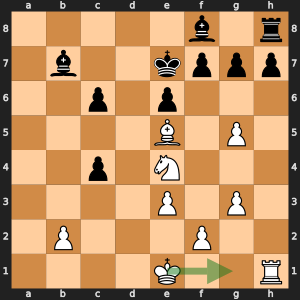

### [5/20] Caruana, Fabiano vs Dominguez Perez, Leinier — White plays O-O (variation)

> 20. O-O for example: 20... Ke8 21. Ra1 c5 22. Nd2 h6 23. Ra7 (and White is clearly better, since the b7-bishop will be forced off the long diagonal.)

*Context: Black gets tangled up after this.*

#### Atom decisions
✅ After O-O, White can play Ra1 and Ra7, forcing the bishop on b7 off the long diagonal.

#### Resulting reasoning
1. After O-O, White can play Ra1 and Ra7, forcing the bishop on b7 off the long diagonal.

#### Alternatives

**Rh4**:
  - Black gets tangled up after Rh4.


#### Variation
`20.O-O Ke8 21.Ra1 c5 22.Nd2 h6 23.Ra7`

**1 → 1 reasoning atoms**

---

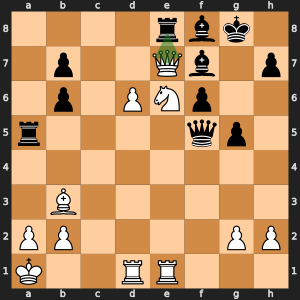

### [6/20] Vaganian, Rafael A vs Moreno Carnero, Javier — White plays Qxe8 (mainline)

> A fitting finish, as 26...Bxe8 is met by 27.Nd4+ regaining the queen with interest.

*Context: A very energetic move, which seals Black's fate.*

#### Atom decisions
✅ Qxe8 wins the rook on e8.

➡️ If Black replies 26...Bxe8, White has 27.Nd4+ and then wins Black's queen. → *alternative (Bxe8)*

  → kept brief: **Qxe8 is strong because 26...Bxe8 fails to 27.Nd4+, after which White wins Black's queen.**

#### Resulting reasoning
1. Qxe8 wins the rook on e8.
2. Qxe8 is strong because 26...Bxe8 fails to 27.Nd4+, after which White wins Black's queen.

#### Alternatives

**Bxe8**:
  - If Black replies 26...Bxe8, White has 27.Nd4+ and then wins Black's queen.


#### Variation
`26...Bxe8 27.Nd4+`

**2 → 2 reasoning atoms (1 → alternative, 1 kept brief)**

---

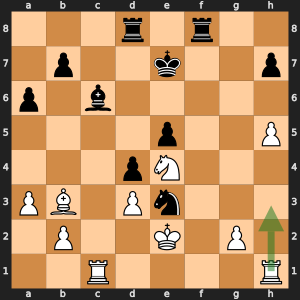

### [7/20] Svidler, Peter vs Vachier Lagrave, Maxime — White plays Rh3 (mainline)

> Losing more material, but after: 29... Nxg2 30. Rxc6 (White tries to keep his strong e4-knight, but his position is beyond salvation.) bxc6 31. Rg3 Nf4+ 32. Ke1 Rb8 33. Rg7+ Kd8 34. Bf7 Rb7

*Context: Black installs the deadly 'octopus' knight!*

#### Atom decisions
✅ After Rh3, Black can win more material with Nxg2.

➡️ After 29...Nxg2 30.Rxc6 bxc6, White tries to preserve the knight on e4, but the position remains lost. → *alternative (Nxg2)*

#### Resulting reasoning
1. After Rh3, Black can win more material with Nxg2.

#### Alternatives

**Nxg2**:
  - After 29...Nxg2 30.Rxc6 bxc6, White tries to preserve the knight on e4, but the position remains lost.


#### Variation
`29...Nxg2 30.Rxc6 bxc6 31.Rg3 Nf4+ 32.Ke1 Rb8 33.Rg7+ Kd8 34.Bf7 Rb7`

**2 → 1 reasoning atoms (1 → alternative)**

---

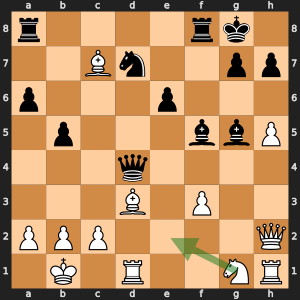

### [8/20] Kokarev, Dmitry vs Dvoirys, Semen I — White plays Ne2 (variation)

> 22. Ne2 that loose knight on d7 is going to cost Black serious material.

*Context: would be an issue, but after*

#### Atom decisions
✅ Ne2 attacks the loose knight on d7, and Black is going to lose serious material because of that knight's vulnerability.

#### Resulting reasoning
1. Ne2 attacks the loose knight on d7, and Black is going to lose serious material because of that knight's vulnerability.

**1 → 1 reasoning atoms**

---

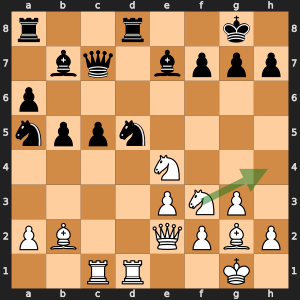

### [9/20] Durarbayli, Vasif vs Yu, Yangyi — White plays Nh4 (mainline)

> Trying to go to f5 and force Black to open the long diagonal for White's bishop, but there are no real threats on the diagonal, so Nh4 is not so effective.

*Context: The computer doesn't like this move, but the position is not easy to understand. Changing the knights instead of 17.Ne4 could hold the balance, but with good practical chances.*

#### Atom decisions
✅ Nh4 intends to reroute the knight to f5.

✅ The idea of Nh4 is to induce Black to open the long diagonal for White's bishop.

🔄 There are no real threats on the long diagonal, so this plan is not effective.

  → **After Nh4, there are no real threats on the long diagonal for White's bishop, so this plan is not effective.**

#### Resulting reasoning
1. Nh4 intends to reroute the knight to f5.
2. The idea of Nh4 is to induce Black to open the long diagonal for White's bishop.
3. After Nh4, there are no real threats on the long diagonal for White's bishop, so this plan is not effective.

**3 → 3 reasoning atoms (1 contextualized)**

---

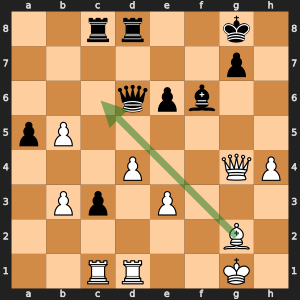

### [10/20] Anton Guijarro, David vs Adams, Michael — White plays Bc6 (variation)

> 41. Bc6 closing the c-file, is also very strong.

*Context: The position looks messy at first sight, but Anton finishes the game off very confidently. Not only is White up a pawn, but he is able to leverage the opposite coloured bishops to execute a strong attack.*

#### Atom decisions
✅ Bc6 closes the c-file.

#### Resulting reasoning
1. Bc6 closes the c-file.

#### Alternatives

**Bf1**:
  - Bf1 is the mainline move the annotator compares against.


**1 → 1 reasoning atoms**

---

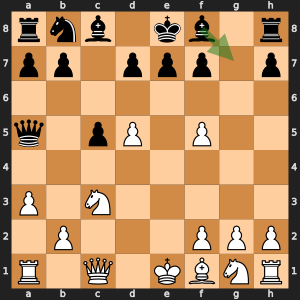

### [11/20] Nyman, Sture vs Bern, Ivar — Black plays Bg7 (mainline)

> Black has swapped his doubled f-pawn defect, as well as his weakness on f5! Gaining a strong mobile queenside majority in the process, supported by a bishop on g7 which is stronger than ever. Taking into account every standard of evaluation, the last 4 moves should represent an improvement of his position. On the other hand, the cover of his king has been slightly altered and White should play actively to demonstrate the pertinence of this.

*Context: White reserves the c3 square for his queen's knight and thus consolidates his strong point on d5 so that the idea of attacking it by means of ...Na6-c7 should be less effective. Unfortunately for him, the opening of the long diagonal for the enemy king's bishop presents Black with a wide range of opportunities, linked to his ensuing dark-squared domination, to try and take advantage of this factor. Indeed, although that famous theoretician GM Igor Stohl (or maybe was it Ernst? And then which one, the Swedish GM or the Dutch IM? It is never clear with the ChessBase multi-commented games....) even labelled this line dubious, in '94, it has been advocated by some strong players, seduced by the superior pawn structure. This has to be considered a minor line compared to 6. g3 when you take into account all its 'suspect, obscure areas'. And the first of them is*

#### Atom decisions
✅ Bg7 supports Black's queenside pawn majority.

✅ The bishop on g7 is stronger than before on the opened long diagonal.

🔄 By the last sequence of moves, Black has eliminated his doubled f-pawns and the weakness on f5.

  → **After the last sequence of moves leading up to Bg7, Black has eliminated his doubled f-pawns and the weakness on f5.**

✅ Black's king cover has been slightly weakened, so White should seek active play against it.

#### Resulting reasoning
1. Bg7 supports Black's queenside pawn majority.
2. The bishop on g7 is stronger than before on the opened long diagonal.
3. After the last sequence of moves leading up to Bg7, Black has eliminated his doubled f-pawns and the weakness on f5.
4. Black's king cover has been slightly weakened, so White should seek active play against it.

**4 → 4 reasoning atoms (1 contextualized)**

---

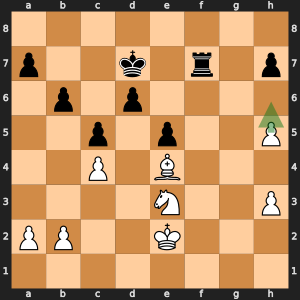

### [12/20] Damljanovic, Branko vs Kindermann, Stefan — White plays h6 (mainline)

> Fixing the h7-pawn on a light square, Black's extra central pawns have no future.

*Context: Now White has two extra pawns when compared with the similar ending considered in the last note, and this added to his light-squared control makes all the difference.*

#### Atom decisions
✅ h6 fixes the h7-pawn on a light square.

✅ With the h7-pawn fixed and White controlling light squares, Black's extra central pawns have no future.

#### Resulting reasoning
1. h6 fixes the h7-pawn on a light square.
2. With the h7-pawn fixed and White controlling light squares, Black's extra central pawns have no future.

**2 → 2 reasoning atoms**

---

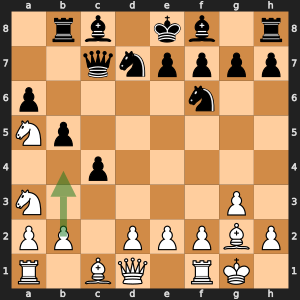

### [13/20] Dubov, Daniil vs Anton Guijarro, David — White plays b4 (variation)

> 10. b4 is an interesting attempt to freeze Black's queenside.

*Context: The alternative is less convincing:*

#### Atom decisions
✅ b4 aims to freeze Black's queenside.

#### Resulting reasoning
1. b4 aims to freeze Black's queenside.

**1 → 1 reasoning atoms**

---

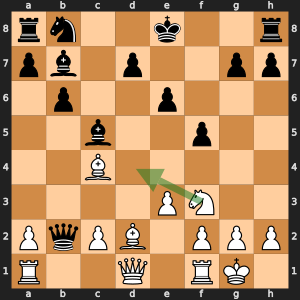

### [14/20] Kramnik, Vladimir vs Svidler, Peter — White plays Nd4 (variation)

> 11. Nd4 which sets many practical problems: 11... Bxd4 12. Rb1 Qa3 13. exd4 (with adequate compensation (two bishops, dark squares, safer king).); or 11... Qa3 12. Nb5 Qa4 13. Qh5+ g6 14. Qh4 (with tricky play)

*Context: then White has*

#### Atom decisions
✅ Nd4 creates practical problems for Black.

➡️ After 11...Bxd4 12.Rb1 Qa3 13.exd4, White has compensation in the two bishops, control of the dark squares, and the safer king. → *alternative (Bxd4)*

➡️ After 11...Qa3 12.Nb5 Qa4 13.Qh5+ g6 14.Qh4, White gets tricky play. → *alternative (Qa3)*

#### Resulting reasoning
1. Nd4 creates practical problems for Black.

#### Alternatives

**Bxd4**:
  - After 11...Bxd4 12.Rb1 Qa3 13.exd4, White has compensation in the two bishops, control of the dark squares, and the safer king.

**Qa3**:
  - After 11...Qa3 12.Nb5 Qa4 13.Qh5+ g6 14.Qh4, White gets tricky play.


#### Variation
`11...Bxd4 12.Rb1 Qa3 13.exd4; or 11...Qa3 12.Nb5 Qa4 13.Qh5+ g6 14.Qh4`

**3 → 1 reasoning atoms (2 → alternative)**

---

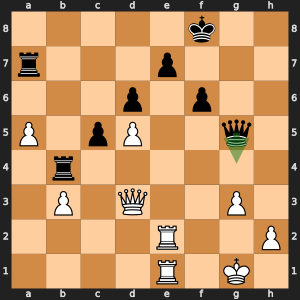

### [15/20] Gustafsson, Jan vs Kasparov, Sergey — Black plays Qg4 (variation)

> 33...Qg4 causes real trouble - black has little to fear in an ending, which will be hard to avoid once he centralises his queen.

*Context: Surprisingly , Black grabs just enough activity to create trouble. One reason is the weakness on d5, the other is that the Ra7 is not so far from the action as it appears.*

#### Atom decisions
✅ Qg4 centralizes Black's queen.

✅ After Qg4, an endgame is hard for White to avoid.

✅ Black has little to fear in the resulting endgame.

#### Resulting reasoning
1. Qg4 centralizes Black's queen.
2. After Qg4, an endgame is hard for White to avoid.
3. Black has little to fear in the resulting endgame.

#### Alternatives

**Rd4**:
  - Rd4 is the mainline move compared against Qg4.


**3 → 3 reasoning atoms**

---

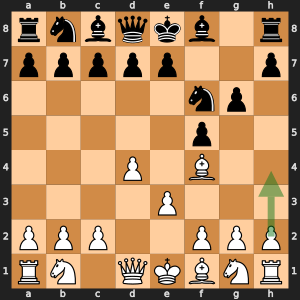

### [16/20] Paravyan, David vs Carlsen, Magnus — White plays h4 (mainline)

> Very logical, especially now that White has not blocked the Queen's route to h5. h4-h5 is an annoying idea, so Magnus next move seems rather forced to me.

*Context: Wow! This is similar to the system that I recommended Black should play against the London, does that mean that Magnus is a secret reader of Chess Publishing? Magnus are you out there reading this? Saying all of the above, I would first start with ...e6 and only then ...g6. As this move does very much encourage the following plan from White.*

#### Atom decisions
✅ White has kept the queen's route to h5 open.

✅ h4 prepares the annoying advance h5.

#### Resulting reasoning
1. White has kept the queen's route to h5 open.
2. h4 prepares the annoying advance h5.

**2 → 2 reasoning atoms**

---

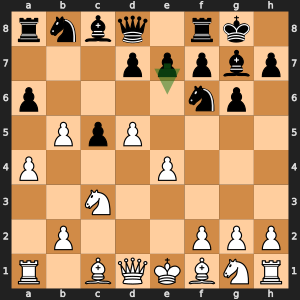

### [17/20] Gonda, Laszlo vs Perunovic, Milos — Black plays e6 (variation)

> 8...e6 has been played, it allows the following option for White: 9. e5 (but this can be countered satisfactorily with the following precise sequence:) Nxd5 10. Nxd5 exd5 11. Qxd5 Ra7 12. Nf3 axb5 13. Bxb5 Qa5+ 14. Qd2 Qc7 (when most Benko players would be happy enough with their compensation.)

*Context: With this move White spends a tempo in order to consolidate his d5-point whilst opening the c1-h6 diagonal. It is indeed quite early in the game for the luxury of a second, unforced, move with the e-pawn, but the plan of maintaining b5 and d5 in this way is quite common.*

#### Atom decisions
✅ e6 allows White the option of advancing e5.

#### Resulting reasoning
1. e6 allows White the option of advancing e5.

#### Alternatives

**Bb7**:
  - Bb7 is the mainline move instead of e6 in this position.


#### Variation
`9.e5 Nxd5 10.Nxd5 exd5 11.Qxd5 Ra7 12.Nf3 axb5 13.Bxb5 Qa5+ 14.Qd2 Qc7`

**1 → 1 reasoning atoms**

---

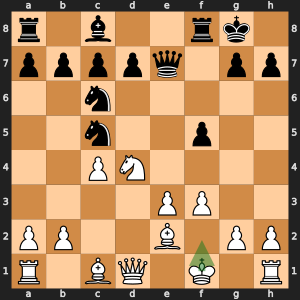

### [18/20] Caruana, Fabiano vs Ding, Liren — White plays Kf2 (mainline)

> White is trying to castle by hand without loosening his kingside with g2-g3 as in the previous note.

*Context: White has also played:*

#### Atom decisions
✅ Kf2 starts castling by hand.

✅ Kf2 avoids loosening White's kingside with g2-g3.

#### Resulting reasoning
1. Kf2 starts castling by hand.
2. Kf2 avoids loosening White's kingside with g2-g3.

**2 → 2 reasoning atoms**

---

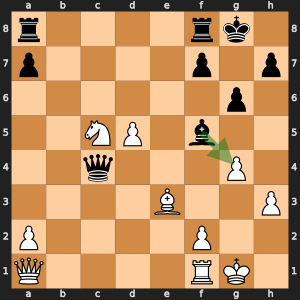

### [19/20] Baumegger, Siegfried vs Eisenbeiser, Amadeus — Black plays Bxg4 (variation)

> 21...Bxg4 when White could find nothing more than allowing the perpetual after: 22. Rc1 Qe2 23. Bh6 f6 24. Bxf8 Rxf8 25. hxg4 Qxg4+ (.)

*Context: when it looked like Black was in some trouble, but he found*

#### Atom decisions
✅ Bxg4 leads to a line where White can do no better than allow a perpetual check.

#### Resulting reasoning
1. Bxg4 leads to a line where White can do no better than allow a perpetual check.

#### Variation
`22.Rc1 Qe2 23.Bh6 f6 24.Bxf8 Rxf8 25.hxg4 Qxg4+`

**1 → 1 reasoning atoms**

---

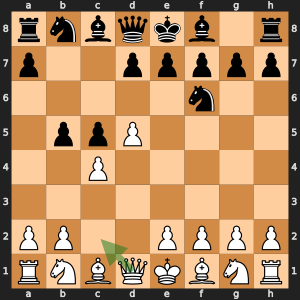

### [20/20] Melkumyan, Hrant vs Andriasian, Zaven — White plays Qc2 (mainline)

> Intending to play e2-e4.

#### Atom decisions
✅ Qc2 prepares the pawn advance e2-e4.

#### Resulting reasoning
1. Qc2 prepares the pawn advance e2-e4.

**1 → 1 reasoning atoms**

---

In [6]:
for idx, (row, result, out_row) in enumerate(sample_results):
    board = chess.Board(row['fen'])
    move = chess.Move.from_uci(row['move_uci'])
    move_san = board.san(move)

    svg = chess.svg.board(
        board,
        arrows=[(move.from_square, move.to_square)],
        size=300,
    )
    display(SVG(svg))

    turn = 'White' if board.turn == chess.WHITE else 'Black'
    loc = 'mainline' if row.get('is_mainline') else 'variation'
    display(Markdown(
        f'### [{idx+1}/{len(sample_results)}] {row["game"]} \u2014 '
        f'{turn} plays {move_san} ({loc})'
    ))

    display(Markdown(f'> {row["annotation"]}'))

    if row.get('parent_comment'):
        display(Markdown(f'*Context: {row["parent_comment"]}*'))

    # Show LLM decisions per reasoning atom
    atoms = result.get('atoms', [])
    if atoms:
        lines = []
        for a in atoms:
            action = a.get('action', 'keep')
            if action == 'keep':
                lines.append(f'\u2705 {a["text"]}')
            elif action == 'remove':
                reason = f' \u2014 *{a["reason"]}*' if a.get('reason') else ''
                lines.append(f'\u274c {a["text"]}{reason}')
            elif action == 'move_to_alternative':
                alt_move = a.get('move', '?')
                lines.append(f'\u27a1\ufe0f {a["text"]} \u2192 *alternative ({alt_move})*')
                if a.get('kept_brief'):
                    lines.append(f'  \u2192 kept brief: **{a["kept_brief"]}**')
            elif action == 'contextualize':
                lines.append(f'\U0001f504 {a["text"]}')
                if a.get('new_text'):
                    lines.append(f'  \u2192 **{a["new_text"]}**')
        display(Markdown('#### Atom decisions\n' + '\n\n'.join(lines)))

    # Show resulting reasoning
    new_r = result['filtered_reasoning']
    if new_r:
        display(Markdown('#### Resulting reasoning\n' +
                         '\n'.join(f'{i+1}. {a}' for i, a in enumerate(new_r))))

    # Show alternatives
    new_alt = out_row['extracted'].get('alternative')
    if new_alt:
        alts = new_alt if isinstance(new_alt, list) else [new_alt]
        alt_blocks = []
        for a in alts:
            block = f'**{a["move"]}**:\n'
            for r in a.get('reasoning', []):
                block += f'  - {r}\n'
            alt_blocks.append(block)
        display(Markdown('#### Alternatives\n\n' + '\n'.join(alt_blocks)))

    # Show variation if present
    var = row['extracted'].get('variation')
    if var:
        display(Markdown(f'#### Variation\n`{var}`'))

    old_r = row['extracted'].get('reasoning', [])
    n_moved = len(result.get('alternatives', []))
    n_ctx = sum(1 for a in atoms if a.get('action') == 'contextualize')
    n_removed = sum(1 for a in atoms if a.get('action') == 'remove')
    n_brief = sum(1 for a in atoms if a.get('kept_brief'))

    summary = f'**{len(old_r)} \u2192 {len(new_r)} reasoning atoms'
    parts = []
    if n_removed > 0:
        parts.append(f'{n_removed} removed')
    if n_ctx > 0:
        parts.append(f'{n_ctx} contextualized')
    if n_moved > 0:
        parts.append(f'{n_moved} \u2192 alternative')
    if n_brief > 0:
        parts.append(f'{n_brief} kept brief')
    if parts:
        summary += f' ({", ".join(parts)})'
    summary += '**'
    display(Markdown(summary))

    display(Markdown('---'))

In [7]:
total_before = 0
total_after = 0
removed_reasons = []
ctx_count = 0
moved_count = 0

for row, result, out_row in sample_results:
    old = row['extracted'].get('reasoning', [])
    total_before += len(old)
    total_after += len(result['filtered_reasoning'])
    for a in result.get('atoms', []):
        action = a.get('action', 'keep')
        if action == 'remove':
            removed_reasons.append(a.get('reason', '?'))
        elif action == 'contextualize':
            ctx_count += 1
        elif action == 'move_to_alternative':
            moved_count += 1

net_change = total_before - total_after
print(f'Sample: {total_before} reasoning atoms -> {total_after} ({net_change} net removed, {net_change/max(total_before,1)*100:.1f}%)')
print(f'  Contextualized: {ctx_count}')
print(f'  Moved to alternative: {moved_count}')
print(f'  Removed: {len(removed_reasons)}')
if removed_reasons:
    print(f'\nRemoval reasons:')
    for r in removed_reasons:
        print(f'  - {r}')

Sample: 40 reasoning atoms -> 35 (5 net removed, 12.5%)
  Contextualized: 5
  Moved to alternative: 6
  Removed: 0


---
# Full run

Run filter on all positions.

In [8]:
OUTPUT_PATH = os.path.join(DIR, 'data', 'extraction_included_filtered.jsonl')
EXCLUDED_PATH = os.path.join(DIR, 'data', 'extraction_excluded_filtered.jsonl')

# Resume support
already_done = set()
for path in [OUTPUT_PATH, EXCLUDED_PATH]:
    if os.path.exists(path):
        with open(path) as f:
            for line in f:
                already_done.add(json.loads(line)['custom_id'])
if already_done:
    print(f'Resuming: {len(already_done)} already done')

n_processed = 0
n_atoms_before = 0
n_atoms_after = 0
n_ctx = 0
n_moved = 0
n_excluded = 0

for row in all_rows:
    if row['custom_id'] in already_done:
        continue

    board = chess.Board(row['fen'])
    san = board.san(chess.Move.from_uci(row['move_uci']))

    result, out_row = run_filter(row)

    old_reasoning = row['extracted'].get('reasoning', [])
    new_reasoning = result['filtered_reasoning']
    n_before = len(old_reasoning)
    n_after = len(new_reasoning)
    n_atoms_before += n_before
    n_atoms_after += n_after
    n_ctx += sum(1 for a in result.get('atoms', []) if a.get('action') == 'contextualize')
    n_moved += len(result.get('alternatives', []))

    out_row['filter_result'] = result.get('atoms', [])

    if not new_reasoning:
        out_row['exclude_reason'] = 'no reasoning atoms after filter'
        with open(EXCLUDED_PATH, 'a') as f:
            f.write(json.dumps(out_row) + '\n')
        n_excluded += 1
        print(f'  [{row["custom_id"]}] {row["game"]} \u2014 {san}: EXCLUDED (0 reasoning atoms)')
    else:
        with open(OUTPUT_PATH, 'a') as f:
            f.write(json.dumps(out_row) + '\n')

    n_processed += 1
    if n_processed % 50 == 0:
        print(f'  {n_processed}/{len(all_rows) - len(already_done)} done '
              f'({n_atoms_before} -> {n_atoms_after} atoms)')
    elif n_before != n_after and new_reasoning:
        print(f'  [{row["custom_id"]}] {row["game"]} \u2014 {san}: {n_before} -> {n_after}')

print(f'\nDone. {n_processed} positions filtered.')
print(f'Included: {n_processed - n_excluded} | Excluded: {n_excluded}')
print(f'Atoms: {n_atoms_before} -> {n_atoms_after} '
      f'({n_atoms_before - n_atoms_after} net removed, '
      f'{(n_atoms_before - n_atoms_after) / max(n_atoms_before, 1) * 100:.1f}%)')
print(f'  Contextualized: {n_ctx}, Moved to alternative: {n_moved}')

  [pos_000005] Azmaiparashvili, Zurab vs Mahjoob, Morteza — Rab8: 3 -> 2
  [pos_000095] Jakovenko, Dmitrij vs Sandipan, Chanda — a3: EXCLUDED (0 reasoning atoms)
  [pos_000121] Amin, Bassem vs Sadhwani, Raunak — h5: EXCLUDED (0 reasoning atoms)
  [pos_000154] Maghsoodloo, Parham vs Karjakin, Sergey — Nd4: EXCLUDED (0 reasoning atoms)
  50/204 done (79 -> 71 atoms)
  [pos_000211] Ponomariov, Ruslan vs Motylev, Alexander — fxg3: 2 -> 1
  [pos_000212] Yermolinsky, Alex vs Plaskett, H James — g5: 2 -> 1
  [pos_000237] Grischuk, Alexander vs Caruana, Fabiano — Rc1: EXCLUDED (0 reasoning atoms)
  [pos_000259] Boruchovsky, Avital vs Caruana, Fabiano — d5: EXCLUDED (0 reasoning atoms)
  [pos_000312] Ding, Liren vs Van Foreest, Jorden — h5: EXCLUDED (0 reasoning atoms)
  [pos_000352] Aronian, Levon vs Karjakin, Sergey — Bxf6: 3 -> 1
  [pos_000392] Schlosser, Philipp vs Naumann, Alexander — Qb6+: 2 -> 1
  100/204 done (163 -> 146 atoms)
  [pos_000447] Svidler, Peter vs Vachier Lagrave, Maxime — 